In [2]:
import pandas as pd
import matplotlib.pyplot as plt

business = pd.read_csv('../data/business_master_cleaned.csv')
products = pd.read_csv('../data/raw/olist_products_dataset.csv')
order_items = pd.read_csv('../data/raw/olist_order_items_dataset.csv')
translation = pd.read_csv('../data/raw/product_category_name_translation.csv')

business['order_purchase_timestamp'] = pd.to_datetime(
    business['order_purchase_timestamp']
)

In [3]:
#Monthly Revenue Trend 
business['year_month'] = business['order_purchase_timestamp'].dt.to_period('M')

monthly_revenue = business.groupby('year_month').agg(
    revenue=('total_revenue', 'sum'),
    orders=('order_id', 'nunique')
).reset_index()

monthly_revenue['year_month'] = monthly_revenue['year_month'].astype(str)

monthly_revenue.head()

,year_month,revenue,orders
0,2016-09,143.46,1
1,2016-10,46490.66,265
2,2016-12,19.62,1
3,2017-01,127482.37,750
4,2017-02,271239.32,1653


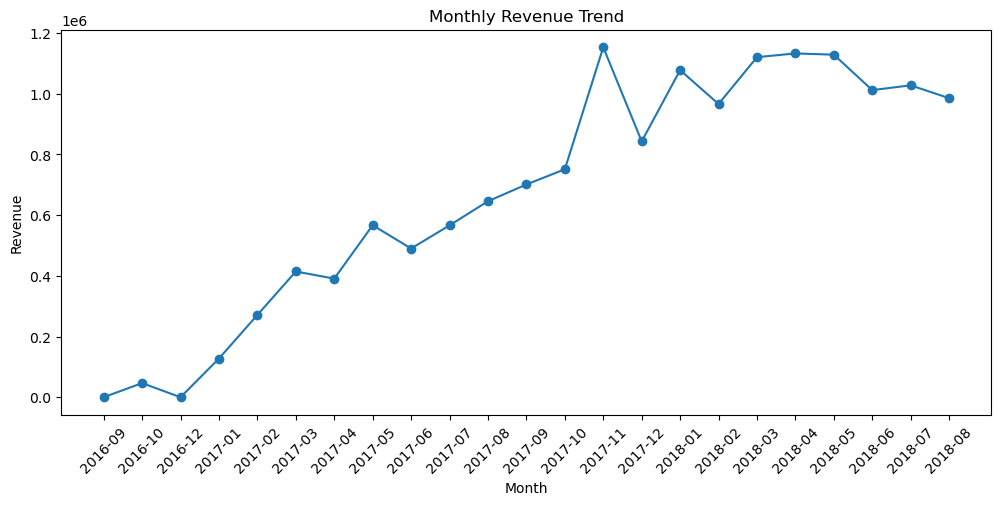

In [4]:
plt.figure(figsize=(12,5))

plt.plot(monthly_revenue['year_month'], monthly_revenue['revenue'], marker='o')

plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.xticks(rotation=45)

plt.show()

In [5]:
#New vs Repeat Customers
first_purchase = business.groupby('customer_unique_id')[
    'order_purchase_timestamp'
].min().reset_index()

first_purchase.columns = ['customer_unique_id', 'first_purchase_date']

business = business.merge(first_purchase, on='customer_unique_id', how='left')

In [6]:
business['customer_type'] = business.apply(
    lambda x: 'New'
    if x['order_purchase_timestamp'] == x['first_purchase_date']
    else 'Repeat',
    axis=1
)

business[['customer_unique_id', 'customer_type']].head()

,customer_unique_id,customer_type
0,7c396fd4830fd04220f754e42b4e5bff,Repeat
1,af07308b275d755c9edb36a90c618231,New
2,3a653a41f6f9fc3d2a113cf8398680e8,New
3,7c142cf63193a1473d2e66489a9ae977,New
4,72632f0f9dd73dfee390c9b22eb56dd6,New


In [7]:
customer_type_revenue = business.groupby('customer_type').agg(
    revenue=('total_revenue', 'sum'),
    orders=('order_id', 'nunique')
)

customer_type_revenue

,revenue,orders
customer_type,,
New,14994880.14,93613
Repeat,424893.61,2865


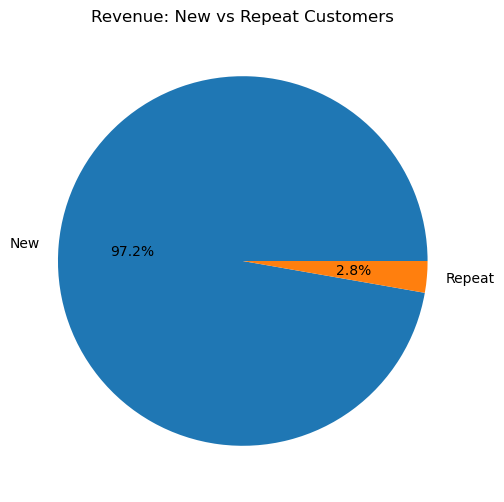

In [8]:
plt.figure(figsize=(6,6))

plt.pie(
    customer_type_revenue['revenue'],
    labels=customer_type_revenue.index,
    autopct='%1.1f%%'
)

plt.title('Revenue: New vs Repeat Customers')

plt.show()

In [9]:
#Top 10 Cities by Revenue
top_cities = business.groupby('customer_city').agg(
    revenue=('total_revenue', 'sum')
).sort_values('revenue', ascending=False).head(10)

top_cities

,revenue
customer_city,
Sao Paulo,2107960.17
Rio De Janeiro,1111732.21
Belo Horizonte,405950.51
Brasilia,345199.05
Curitiba,238459.72
Porto Alegre,214805.84
Campinas,209002.90
Salvador,207713.30
Guarulhos,157735.65


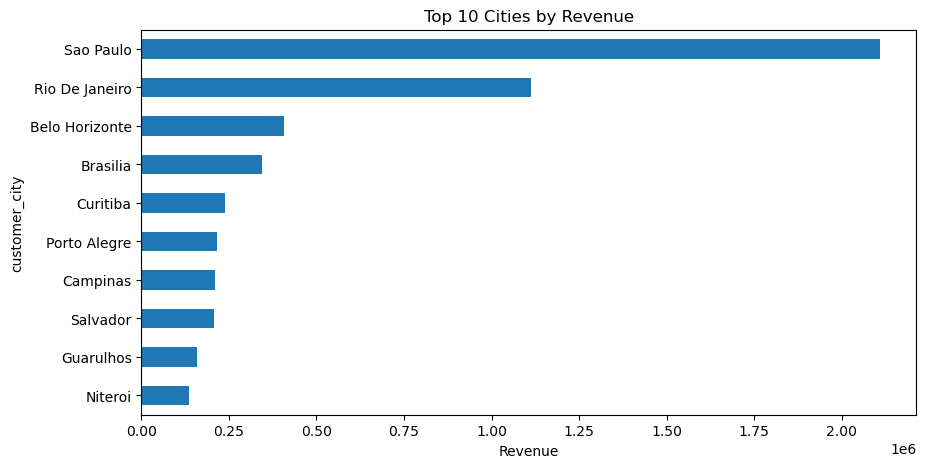

In [10]:
plt.figure(figsize=(10,5))

top_cities['revenue'].sort_values().plot(kind='barh')

plt.title('Top 10 Cities by Revenue')
plt.xlabel('Revenue')

plt.show()

In [11]:
#Top Product Categories
# Merge order items with products
product_sales = order_items.merge(products, on='product_id', how='left')

# Translate category names
product_sales = product_sales.merge(
    translation,
    on='product_category_name',
    how='left'
)

# Revenue by category
category_revenue = product_sales.groupby(
    'product_category_name_english'
).agg(
    revenue=('price', 'sum')
).sort_values('revenue', ascending=False).head(10)

category_revenue

,revenue
product_category_name_english,
health_beauty,1258681.34
watches_gifts,1205005.68
bed_bath_table,1036988.68
sports_leisure,988048.97
computers_accessories,911954.32
furniture_decor,729762.49
cool_stuff,635290.85
housewares,632248.66
auto,592720.11


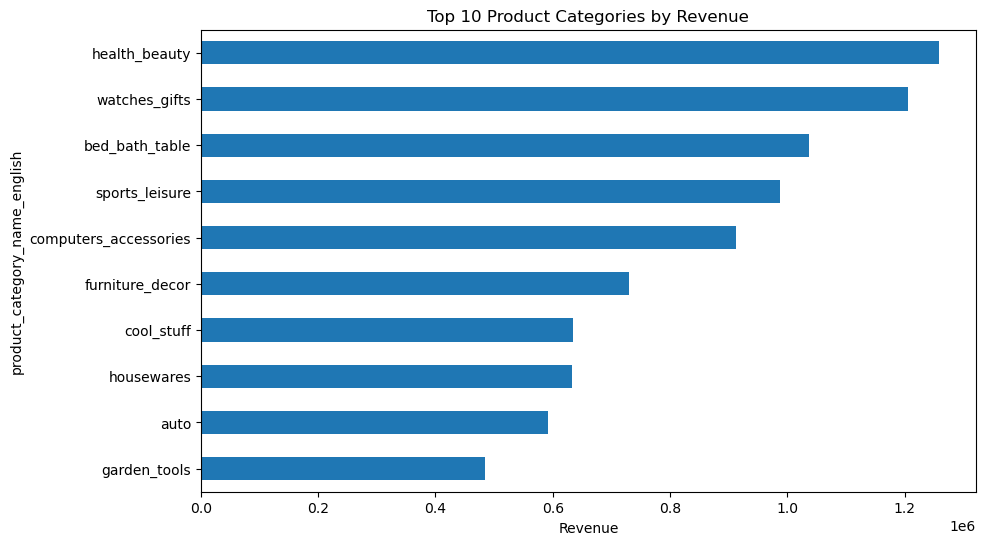

In [12]:
plt.figure(figsize=(10,6))

category_revenue['revenue'].sort_values().plot(kind='barh')

plt.title('Top 10 Product Categories by Revenue')
plt.xlabel('Revenue')

plt.show()

In [13]:
monthly_revenue.to_csv('../data/monthly_revenue.csv', index=False)
customer_type_revenue.to_csv('../data/customer_type_revenue.csv')
top_cities.to_csv('../data/top_cities_revenue.csv')
category_revenue.to_csv('../data/top_category_revenue.csv')

print('Day 3 export complete!')

Day 3 export complete!
